In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv('marketing_campaign_final.csv')

In [3]:
df.head()

,ID,Year_Birth,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,55.0,Graduation,Single,58138,0,0,4/9/2012,58,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,60.0,Graduation,Single,46344,1,1,8/3/2014,38,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,48.0,Graduation,Together,71613,0,0,8/21/2013,26,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,30.0,Graduation,Together,26646,1,0,10/2/2014,26,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,33.0,PhD,Married,58293,1,0,1/19/2014,94,...,3,6,5,0,0,0,0,0,0,0


In [4]:
df.dtypes

ID                       int64
Year_Birth               int64
Age                    float64
Education               object
Marital_Status          object
Income                   int64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
dtype: object

In [5]:
df.isnull().sum()

ID                     0
Year_Birth             0
Age                    0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

In [6]:
df.describe()

,ID,Year_Birth,Age,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,5585.439456,1968.904308,44.123356,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,...,2.645351,5.823583,5.336961,0.073923,0.074376,0.073016,0.064399,0.013605,0.009070,0.15102
std,3247.546423,11.705801,11.742249,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,...,2.798647,3.241796,2.413535,0.261705,0.262442,0.260222,0.245518,0.115872,0.094827,0.35815
min,0.000000,1940.000000,16.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2815.000000,1959.000000,36.000000,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5455.000000,1970.000000,43.000000,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,8418.000000,1977.000000,54.000000,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,11191.000000,1996.000000,73.000000,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


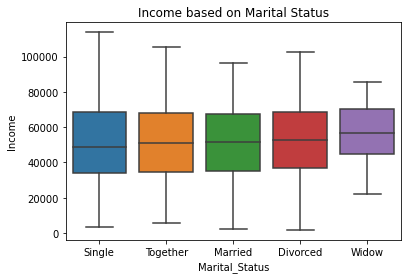

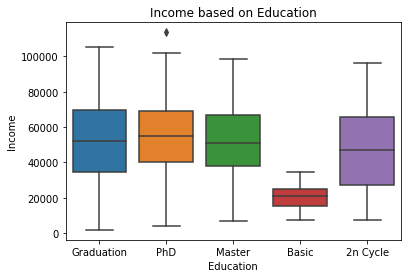

In [7]:
sns.boxplot(x='Marital_Status', y='Income', data=df)
plt.title("Income based on Marital Status")
plt.show()
sns.boxplot(x='Education', y='Income', data=df)
plt.title("Income based on Education")
plt.show()

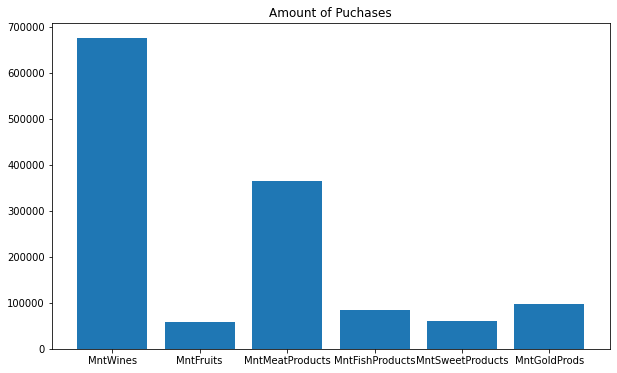

In [8]:
category = ['MntWines', 'MntFruits', 'MntMeatProducts', 
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
totals = df[category].sum()
plt.figure(figsize=(10, 6))
plt.bar(x = totals.index, height = totals.values)
plt.title("Amount of Puchases")
plt.show()

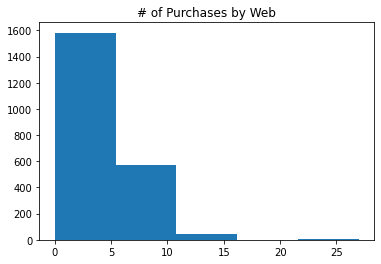

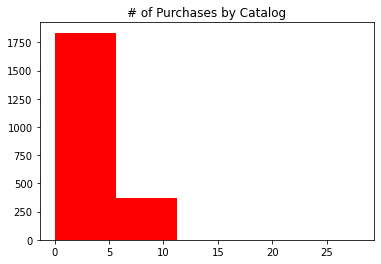

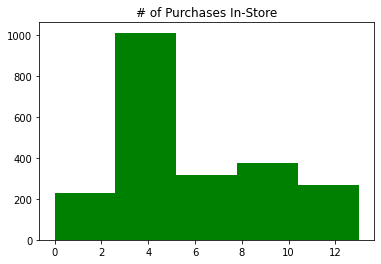

In [9]:
plt.hist(df['NumWebPurchases'], bins = 5)
plt.title("# of Purchases by Web")
plt.show()
plt.hist(df['NumCatalogPurchases'], bins = 5, color = 'red')
plt.title("# of Purchases by Catalog")
plt.show()
plt.hist(df['NumStorePurchases'], bins = 5, color = 'green')
plt.title("# of Purchases In-Store")
plt.show()

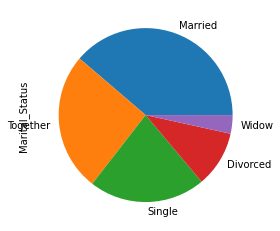

<Figure size 720x432 with 0 Axes>

In [22]:
marital_status_counts = df['Marital_Status'].value_counts()
marital_status_counts.plot(kind='pie')
plt.figure(figsize=(10, 6))
plt.show()

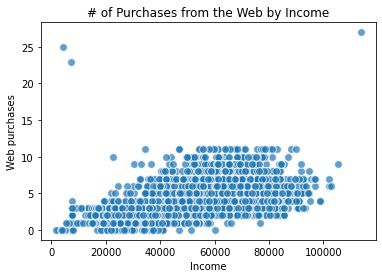

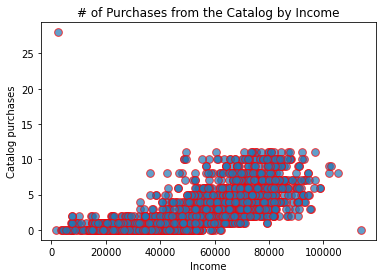

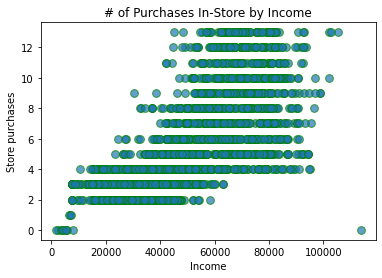

In [15]:
plt.scatter(x=df['Income'], y=df['NumWebPurchases'], alpha=0.7, edgecolors='w', s=60)
plt.title("# of Purchases from the Web by Income")
plt.xlabel('Income')
plt.ylabel('Web purchases')
plt.show()
plt.scatter(x=df['Income'], y=df['NumCatalogPurchases'], alpha=0.7, edgecolors='r', s=60)
plt.title("# of Purchases from the Catalog by Income")
plt.xlabel('Income')
plt.ylabel('Catalog purchases')
plt.show()
plt.scatter(x=df['Income'], y=df['NumStorePurchases'], alpha=0.7, edgecolors='g', s=60)
plt.title("# of Purchases In-Store by Income")
plt.xlabel('Income')
plt.ylabel('Store purchases')
plt.show()

In [12]:
purchase_cols = [ 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'Response']
df_purchase = df[purchase_cols]
purchase_corr = df_purchase.corr()
print(purchase_corr)

                     NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
NumWebPurchases             1.000000             0.420890           0.512109   
NumCatalogPurchases         0.420890             1.000000           0.561261   
NumStorePurchases           0.512109             0.561261           1.000000   
Response                    0.149699             0.234524           0.033509   

                     Response  
NumWebPurchases      0.149699  
NumCatalogPurchases  0.234524  
NumStorePurchases    0.033509  
Response             1.000000  


In [13]:
contingency_table_edu = pd.crosstab(df['Education'], df['Response'])
chi2_stat, p_value, dof, ex = chi2_contingency(contingency_table_edu)
print(chi2_stat, p_value, dof)
contingency_table_rel = pd.crosstab(df['Marital_Status'], df['Response'])
chi2_stat, p_value, dof, ex = chi2_contingency(contingency_table_rel)
print(chi2_stat, p_value, dof)

23.65660714872728 9.358414051001273e-05 4
50.55983045051114 2.758647911255055e-10 4


Exploritory Data Analysis findings:
1. When looking at the boxplots based on Marital Status, there are no anomolies detected, but when using boxplots, there is one anomoly detected.
2. When looking at the histograms and scatter plots based on where the product is purchased, the most reliable data comes from purchases in-store while the catalog and online purchases have a few outlires.
3. the Chi-square test between the response values and the categorial values Education and Marital Status result in the p-values both less than 0.05, meaning we reject the null hypothesis and accept the fact that there is a significant relationship.
4. When looking at the correlation matrix between the different ways to shop and the Response values, then the results show that catalog purchases are more likely to leave a positive view than others.